# CfA Supernova Spectra: Nested Sampling Phase Determination Summary

This notebook compiles and analyzes the results of fitting the CfA SN Ia spectral database using our single-spectrum nested sampling framework. We restrict the sample to rest-frame phases between $-12$ and $+35$ days.

### Key Analysis Steps:
1. Load the results from `data/cfa_fits_results.csv`.
2. Compute the spectroscopically derived rest-frame phase:
   $$A_{\text{spec}} = \frac{T_{\text{spec}} - t_0}{1 + z}$$
3. Compare $A_{\text{spec}}$ against the true photometric rest-frame phase $A_{\text{true}}$ (from `Age_(days)`).
4. Calculate statistics on the residuals: bias, scatter (standard deviation), and robust scatter (MAD).
5. Plot the correlation between true and estimated phase, residual histograms, and phase-dependent trends.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm

%matplotlib inline
plt.style.use('default')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.2

In [2]:
csv_path = '../data/cfa_fits_results.csv'
if not os.path.exists(csv_path):
    raise FileNotFoundError(f"Results file not found at {csv_path}. Make sure the fitting script has run and saved results.")

df = pd.read_csv(csv_path)
print(f"Total rows loaded: {len(df)}")

# Filter to successful fits
df_success = df[df['Status'] == 'Success'].copy()
print(f"Successful fits: {len(df_success)} ({len(df_success)/len(df)*100:.1f}% of total)")

# Compute estimated phase and error
df_success['phase_est'] = (df_success['MJD'] - df_success['t0']) / (1.0 + df_success['redshift'])
df_success['phase_est_err'] = df_success['t0_err'] / (1.0 + df_success['redshift'])
df_success['phase_diff'] = df_success['phase_est'] - df_success['Age_(days)']

df_success.head(10)

Total rows loaded: 1808
Successful fits: 1808 (100.0% of total)


,Filename,SN_Name,redshift,Age_(days),MJD,Status,Error,t0,t0_err,x1,x1_err,c,c_err,chi2_red,phase_est,phase_est_err,phase_diff
0,sn1997cn-19970609.21-fast.flm,1997cn,0.0168,21.744689,50608.21,Success,NaN,50574.145758,0.267854,2.490680,0.402418,-0.017329,0.016654,7.122200,33.501418,0.263429,11.756729
1,sn2004as-20040422.33-fast.flm,2004as,0.0310,30.969932,53117.33,Success,NaN,53082.115810,0.260899,1.087081,0.244441,-0.049740,0.010524,2.835363,34.155373,0.253054,3.185441
2,sn2003hu-20031002.13-fast.flm,2003hu,0.0750,12.120930,52914.13,Success,NaN,52926.020221,0.592486,2.273008,0.154002,0.562113,0.009298,2.647267,-11.060671,0.551149,-23.181601
3,sn1999by-19990513.18-fast.flm,1999by,0.0022,1.975654,51311.18,Success,NaN,51298.962879,0.146164,-1.228351,0.075293,0.218144,0.014535,16.638923,12.190303,0.145843,10.214649
4,sn2001N-20010201.37-fast.flm,2001N,0.0210,10.352595,51941.37,Success,NaN,51933.097162,0.144627,0.203540,0.069949,0.688894,0.004237,6.272430,8.102681,0.141653,-2.249914
5,sn2007F-20070126.43-fast.flm,2007F,0.0236,2.960141,54126.43,Success,NaN,54124.369921,0.058385,0.218936,0.031017,-0.043544,0.001944,1.436856,2.012582,0.057039,-0.947558
6,sn2004at-20040323.24-fast.flm,2004at,0.0223,-4.656167,53087.24,Success,NaN,53092.185108,0.057133,-0.628549,0.021849,-0.026911,0.001725,1.377178,-4.837238,0.055887,-0.181070
7,sn1998es-19981121.23-fast.flm,1998es,0.0106,-4.423115,51138.23,Success,NaN,51142.599822,0.054473,1.834308,0.025268,0.174394,0.001315,1.244720,-4.323988,0.053901,0.099127
8,sn1999ac-19990312.53-fast.flm,1999ac,0.0095,-0.960872,51249.53,Success,NaN,51251.374995,0.065062,-0.439705,0.039540,0.016501,0.002710,3.093153,-1.827633,0.064449,-0.866761
9,sn2001cp-20010627.26-fast.flm,2001cp,0.0224,-1.115023,52087.26,Success,NaN,52087.088992,0.080703,0.884764,0.033749,0.133602,0.001927,1.234775,0.167261,0.078935,1.282285


In [3]:
mean_diff = df_success['phase_diff'].mean()
median_diff = df_success['phase_diff'].median()
std_diff = df_success['phase_diff'].std()

# Robust scatter using MAD
mad_diff = np.median(np.abs(df_success['phase_diff'] - median_diff))
robust_std = 1.4826 * mad_diff

print("=== Phase Determination Metrics ===")
print(f"Mean Bias (Est - True):  {mean_diff:+.3f} days")
print(f"Median Bias:            {median_diff:+.3f} days")
print(f"Scatter (Std Dev):       {std_diff:.3f} days")
print(f"Robust Scatter (MAD):    {robust_std:.3f} days")
print(f"Fraction within 1 day:   {(np.abs(df_success['phase_diff']) <= 1.0).mean()*100:.1f}%")
print(f"Fraction within 2 days:  {(np.abs(df_success['phase_diff']) <= 2.0).mean()*100:.1f}%")

=== Phase Determination Metrics ===
Mean Bias (Est - True):  -1.426 days
Median Bias:            -1.151 days
Scatter (Std Dev):       7.064 days
Robust Scatter (MAD):    2.769 days
Fraction within 1 day:   24.7%
Fraction within 2 days:  48.0%


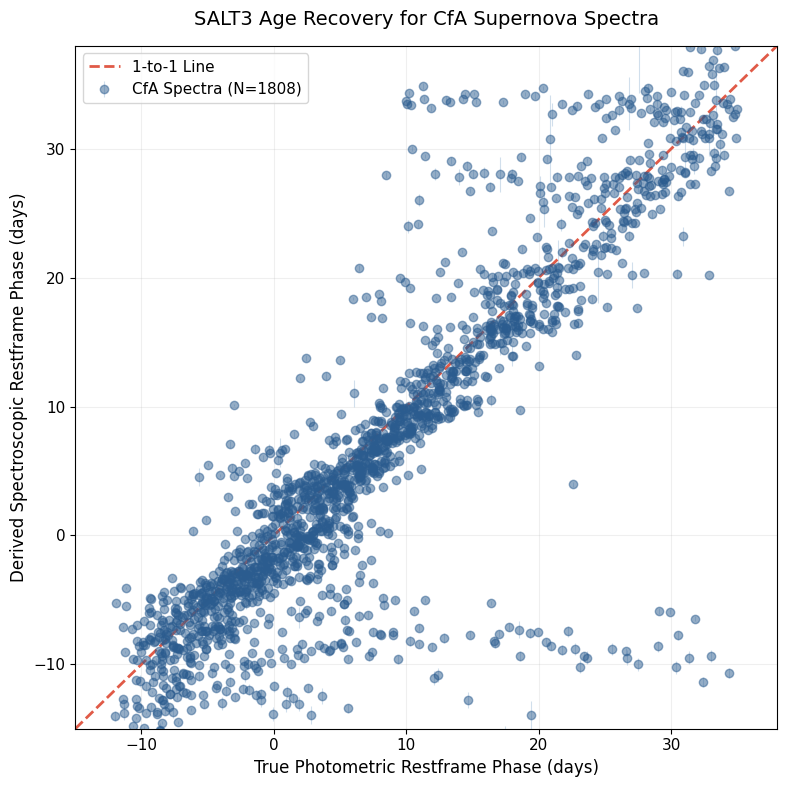

In [4]:
plt.figure(figsize=(8, 8))
plt.errorbar(df_success['Age_(days)'], df_success['phase_est'], 
             yerr=df_success['phase_est_err'], 
             fmt='o', color='#2b5c8f', ecolor='#a5c0db', alpha=0.5, capsize=0, elinewidth=0.8,
             label=f'CfA Spectra (N={len(df_success)})')

# Plot 1-to-1 line
limits = [-15, 38]
plt.plot(limits, limits, color='#e05a47', linestyle='--', lw=2, label='1-to-1 Line')

plt.xlim(limits)
plt.ylim(limits)
plt.xlabel('True Photometric Restframe Phase (days)', fontsize=12)
plt.ylabel('Derived Spectroscopic Restframe Phase (days)', fontsize=12)
plt.title('SALT3 Age Recovery for CfA Supernova Spectra', fontsize=14, pad=15)
plt.legend(loc='upper left', fontsize=11)
plt.tight_layout()
plt.savefig('../outputs/cfa_age_recovery.png', dpi=300)
plt.show()

<>:14: SyntaxWarning: invalid escape sequence '\m'
<>:14: SyntaxWarning: invalid escape sequence '\s'
<>:14: SyntaxWarning: invalid escape sequence '\m'
<>:14: SyntaxWarning: invalid escape sequence '\s'
/var/folders/qn/w0hwzpl9009_4d15fgh446c80000gq/T/ipykernel_44807/4094204441.py:14: SyntaxWarning: invalid escape sequence '\m'
  label=f'Gaussian Fit ($\mu$={mu:+.2f}d, $\sigma$={std_fit:.2f}d)')
/var/folders/qn/w0hwzpl9009_4d15fgh446c80000gq/T/ipykernel_44807/4094204441.py:14: SyntaxWarning: invalid escape sequence '\s'
  label=f'Gaussian Fit ($\mu$={mu:+.2f}d, $\sigma$={std_fit:.2f}d)')


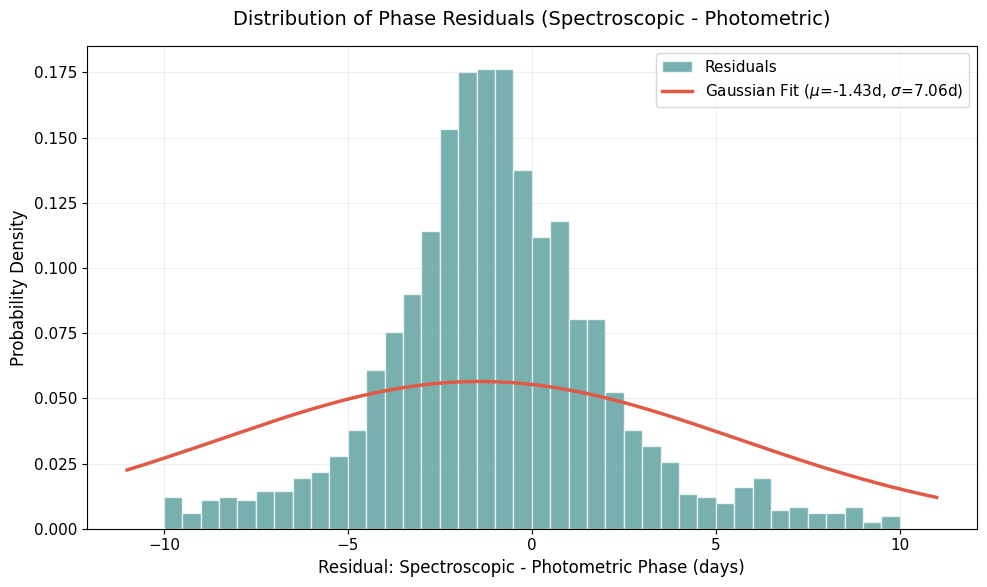

In [5]:
plt.figure(figsize=(10, 6))
residuals = df_success['phase_diff']

# Fit normal distribution
mu, std_fit = norm.fit(residuals)

n, bins, patches = plt.hist(residuals, bins=40, range=(-10, 10), density=True, 
                            color='#3f8f8f', edgecolor='white', alpha=0.7, label='Residuals')

xmin, xmax = plt.xlim()
x_plot = np.linspace(xmin, xmax, 200)
p_plot = norm.pdf(x_plot, mu, std_fit)
plt.plot(x_plot, p_plot, color='#e05a47', lw=2.5, 
         label=f'Gaussian Fit ($\mu$={mu:+.2f}d, $\sigma$={std_fit:.2f}d)')

plt.xlabel('Residual: Spectroscopic - Photometric Phase (days)', fontsize=12)
plt.ylabel('Probability Density', fontsize=12)
plt.title('Distribution of Phase Residuals (Spectroscopic - Photometric)', fontsize=14, pad=15)
plt.legend(fontsize=11)
plt.tight_layout()
plt.savefig('../outputs/cfa_phase_residuals_hist.png', dpi=300)
plt.show()

<>:27: SyntaxWarning: invalid escape sequence '\s'
<>:27: SyntaxWarning: invalid escape sequence '\s'
/var/folders/qn/w0hwzpl9009_4d15fgh446c80000gq/T/ipykernel_44807/2980319715.py:27: SyntaxWarning: invalid escape sequence '\s'
  capsize=4, elinewidth=2, capthick=2, label='Running Binned Median (robust $\sigma$)')


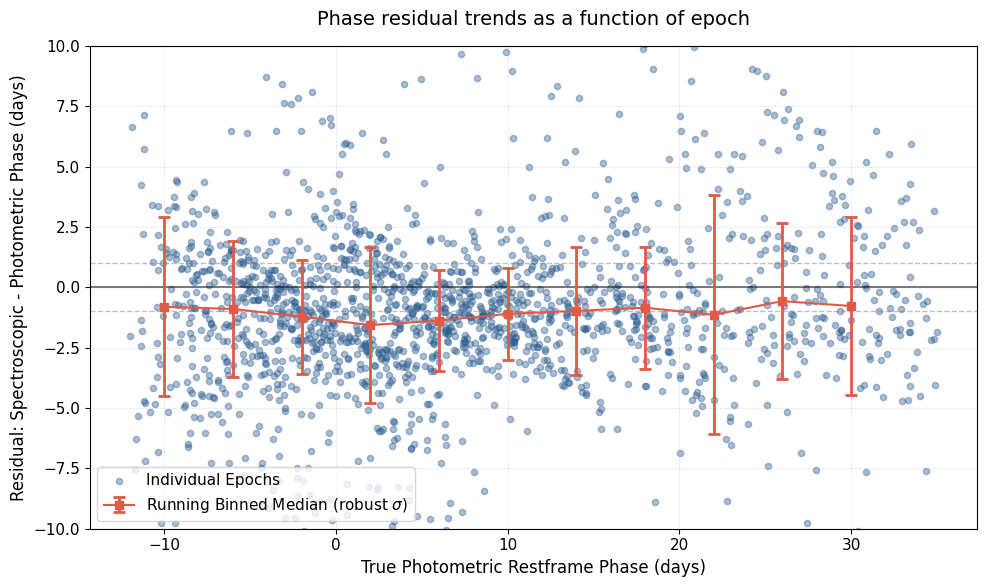

In [6]:
plt.figure(figsize=(10, 6))
plt.scatter(df_success['Age_(days)'], df_success['phase_diff'], 
            color='#2b5c8f', alpha=0.4, s=20, label='Individual Epochs')

plt.axhline(0, color='black', linestyle='-', lw=1.5, alpha=0.5)
plt.axhline(1, color='gray', linestyle='--', lw=1, alpha=0.5)
plt.axhline(-1, color='gray', linestyle='--', lw=1, alpha=0.5)

# Compute binned running median/mean
bins = np.arange(-12, 36, 4)
bin_centers = 0.5 * (bins[:-1] + bins[1:])
binned_mean = []
binned_std = []

for i in range(len(bins)-1):
    mask_bin = (df_success['Age_(days)'] >= bins[i]) & (df_success['Age_(days)'] < bins[i+1])
    if mask_bin.sum() > 2:
        binned_mean.append(df_success.loc[mask_bin, 'phase_diff'].median())
        # robust scatter
        mad_bin = np.median(np.abs(df_success.loc[mask_bin, 'phase_diff'] - binned_mean[-1]))
        binned_std.append(1.4826 * mad_bin)
    else:
        binned_mean.append(np.nan)
        binned_std.append(np.nan)

plt.errorbar(bin_centers, binned_mean, yerr=binned_std, fmt='s-', color='#e05a47', 
             capsize=4, elinewidth=2, capthick=2, label='Running Binned Median (robust $\sigma$)')

plt.xlabel('True Photometric Restframe Phase (days)', fontsize=12)
plt.ylabel('Residual: Spectroscopic - Photometric Phase (days)', fontsize=12)
plt.title('Phase residual trends as a function of epoch', fontsize=14, pad=15)
plt.ylim(-10, 10)
plt.legend(loc='lower left', fontsize=11)
plt.tight_layout()
plt.savefig('../outputs/cfa_residuals_vs_phase.png', dpi=300)
plt.show()

<>:3: SyntaxWarning: invalid escape sequence '\c'
<>:14: SyntaxWarning: invalid escape sequence '\c'
<>:18: SyntaxWarning: invalid escape sequence '\c'
<>:19: SyntaxWarning: invalid escape sequence '\c'
<>:3: SyntaxWarning: invalid escape sequence '\c'
<>:14: SyntaxWarning: invalid escape sequence '\c'
<>:18: SyntaxWarning: invalid escape sequence '\c'
<>:19: SyntaxWarning: invalid escape sequence '\c'
/var/folders/qn/w0hwzpl9009_4d15fgh446c80000gq/T/ipykernel_44807/3504838270.py:3: SyntaxWarning: invalid escape sequence '\c'
  color='#7f5f9f', alpha=0.5, s=20, label='Pre-fit $\chi^2_{\text{red}}$')
/var/folders/qn/w0hwzpl9009_4d15fgh446c80000gq/T/ipykernel_44807/3504838270.py:14: SyntaxWarning: invalid escape sequence '\c'
  plt.plot(bin_centers, binned_chi2, 'o-', color='#e05a47', label='Running Median $\chi^2_{\text{red}}$')
/var/folders/qn/w0hwzpl9009_4d15fgh446c80000gq/T/ipykernel_44807/3504838270.py:18: SyntaxWarning: invalid escape sequence '\c'
  plt.ylabel('Best-fit Reduced $\

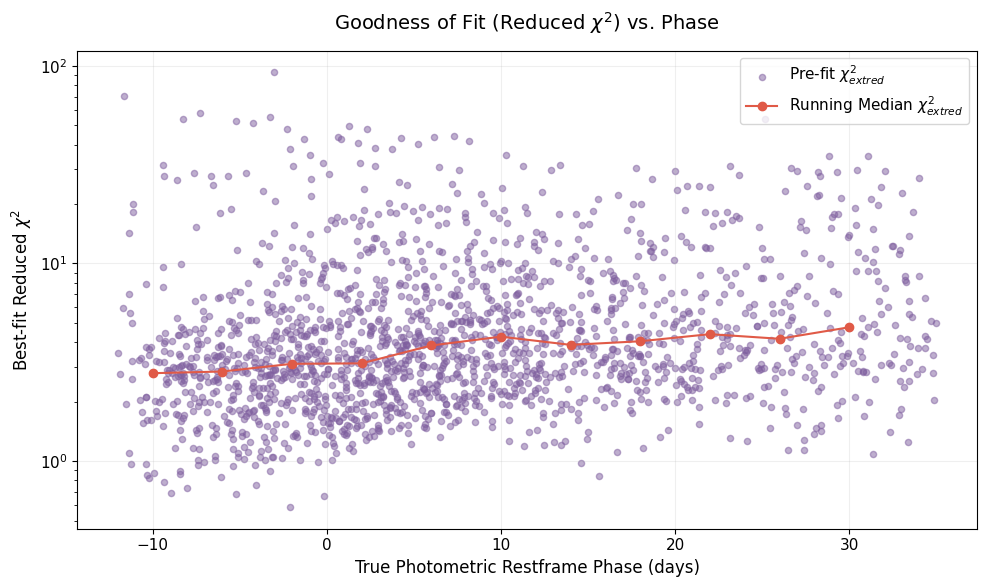

In [7]:
plt.figure(figsize=(10, 6))
plt.scatter(df_success['Age_(days)'], df_success['chi2_red'], 
            color='#7f5f9f', alpha=0.5, s=20, label='Pre-fit $\chi^2_{\text{red}}$')

# running median of chi2_red
binned_chi2 = []
for i in range(len(bins)-1):
    mask_bin = (df_success['Age_(days)'] >= bins[i]) & (df_success['Age_(days)'] < bins[i+1])
    if mask_bin.sum() > 2:
        binned_chi2.append(df_success.loc[mask_bin, 'chi2_red'].median())
    else:
        binned_chi2.append(np.nan)

plt.plot(bin_centers, binned_chi2, 'o-', color='#e05a47', label='Running Median $\chi^2_{\text{red}}$')

plt.yscale('log')
plt.xlabel('True Photometric Restframe Phase (days)', fontsize=12)
plt.ylabel('Best-fit Reduced $\chi^2$', fontsize=12)
plt.title('Goodness of Fit (Reduced $\chi^2$) vs. Phase', fontsize=14, pad=15)
plt.legend(loc='upper right', fontsize=11)
plt.tight_layout()
plt.savefig('../outputs/cfa_chi2_vs_phase.png', dpi=300)
plt.show()